In [1]:
# https://www.kaggle.com/competitions/playground-series-s6e6/overview

import os

import kagglehub

path = kagglehub.competition_download('playground-series-s6e6')

print("Path to competition files:", path)

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Path to competition files: /home/rpsingh/.cache/kagglehub/competitions/playground-series-s6e6
/home/rpsingh/.cache/kagglehub/competitions/playground-series-s6e6/test.csv
/home/rpsingh/.cache/kagglehub/competitions/playground-series-s6e6/train.csv
/home/rpsingh/.cache/kagglehub/competitions/playground-series-s6e6/sample_submission.csv


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import optuna
import lightgbm as lgbm
import catboost as cb
import xgboost as xgb
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn import svm

# Load data

In [3]:
train_df = pd.read_csv("/home/rpsingh/.cache/kagglehub/competitions/playground-series-s6e6/train.csv")
test_df = pd.read_csv("/home/rpsingh/.cache/kagglehub/competitions/playground-series-s6e6/test.csv")

In [4]:
train_df.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


# Data analysis

In [5]:
train_df.isna().sum().sum()

np.int64(0)

In [6]:
test_df.isna().sum().sum()

np.int64(0)

In [7]:
train_df['class'].unique()

<StringArray>
['GALAXY', 'QSO', 'STAR']
Length: 3, dtype: str

<Axes: title={'center': 'Count (target)'}, xlabel='class'>

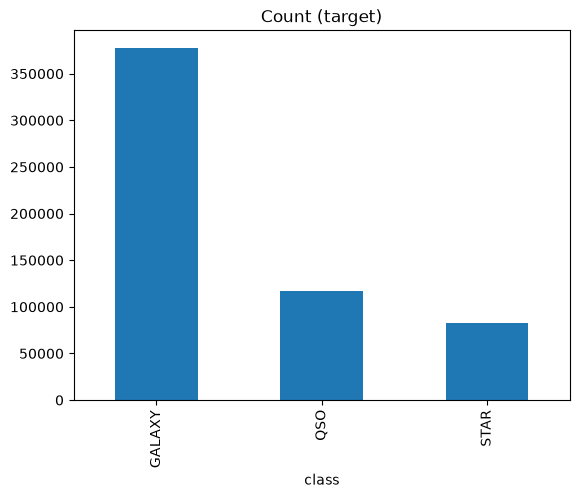

In [8]:
train_df.groupby('class').size().plot(kind='bar', title='Count (target)')

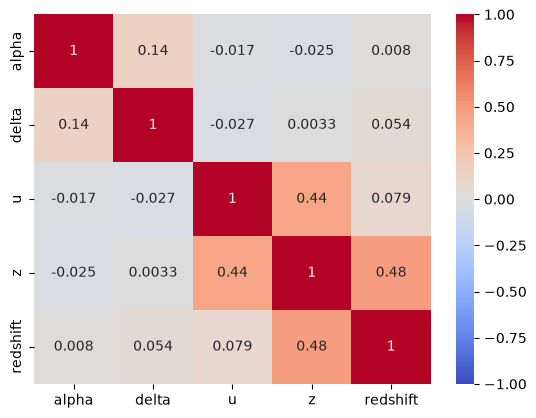

In [26]:
sns.heatmap(train_df[['alpha', 'delta', 'u', 'z', 'redshift']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [ ]:
sns.barplot(train_df, x="")

# Data cleanup

In [13]:
target_column = 'class'
feature_columns = train_df.columns.drop(['id', target_column]).to_list()
num_columns = train_df.select_dtypes('number').columns.drop('id').to_list()
cat_columns = train_df.select_dtypes('str').columns.drop(target_column).to_list()
print(feature_columns, num_columns, cat_columns)

['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population'] ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift'] ['spectral_type', 'galaxy_population']


In [ ]:
x_train, y_train = train_df[feature_columns], train_df[target_column]
x_test = test_df[feature_columns]
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape : {x_test.shape}")

x_train shape: (577347, 10)
y_train shape: (577347,)
x_test shape : (247435, 10)


## Encoding

In [ ]:
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train)

for col in cat_columns:
    all_rows = pd.concat([x_train[col], x_test[col]], axis=0).astype('string')
    col_encoder = LabelEncoder()
    col_encoder.fit(all_rows)
    x_train[col] = col_encoder.transform(x_train[col].astype('string'))
    x_test[col] = col_encoder.transform(x_test[col].astype('string'))

x_train.head()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,2,1
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,2,1
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,3,0
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,2,1
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,2,1


In [ ]:
x_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  int64  
 9   galaxy_population  577347 non-null  int64  
dtypes: float64(8), int64(2)
memory usage: 44.0 MB


# Hyperparameter tuning with Optuna

## LightGBM

In [ ]:
def lgbm_objective(trial):
    params = {
        # Core Parameters for Binary Probability
        "objective": "multiclass",
        # "metric": "auc_mu", # multi_logloss
        "metric": "multi_logloss",
        "boosting_type": "gbdt",
        "n_estimators": trial.suggest_int("n_estimators", 100, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 1e-2, 2e-1, log=True),
        
        # Structural Parameters (Tree Complexity)
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        
        # Regularization (To prevent overfitting)
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        
        # Subsampling (Stochastic behavior)
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),

        'early_stopping_rounds': 100,
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': -1,
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []
    for train_idx, val_idx in skf.split(x_train, y_train):
        x_train_fold, y_train_fold = x_train.iloc[train_idx], y_train[train_idx]
        x_val_fold, y_val_fold = x_train.iloc[val_idx], y_train[val_idx]

        model = lgbm.LGBMClassifier(**params)
        model.fit(x_train_fold, y_train_fold, eval_X=x_val_fold, eval_y=y_val_fold)

        preds = model.predict(x_val_fold)
        score = balanced_accuracy_score(y_val_fold, preds)
        cv_scores.append(score)
    return np.mean(cv_scores)


In [ ]:
lgbm_study = optuna.create_study(
    storage="sqlite:///optuna.db",
    load_if_exists=True,
    direction="maximize",
    study_name="lgbm_study"
)
# lgbm_study.optimize(lgbm_objective, n_trials=25, n_jobs=1, show_progress_bar=True)

[I 2026-08-14 07:16:56,182] Using an existing study with name 'lgbm_study' instead of creating a new one.


In [ ]:
optuna.visualization.plot_optimization_history(lgbm_study)

In [ ]:
optuna.visualization.plot_param_importances(lgbm_study)

In [ ]:
lgbm_best_params = lgbm_study.best_params.copy()
lgbm_best_params.update({
    "random_state": 42, "verbose": -1, "n_jobs": -1,
    "objective": "multiclass",
    "metric": "multi_logloss",
})
lgbm_final_model = lgbm.LGBMClassifier(**lgbm_best_params)

In [ ]:
lgbm_final_model.fit(x_train, y_train)
predications = lgbm_final_model.predict(x_test)
lable_prediction = target_encoder.inverse_transform(predications)

lgbm_submission = pd.DataFrame({'id': test_df['id'], 'class': lable_prediction})
lgbm_submission.to_csv('output/lgbm_submission.csv', index=False)

joblib.dump(lgbm_final_model, 'output/lgbm_final_model.pkl')

['data/lgbm_final_model.pkl']

## Catboost

In [ ]:
def cv_k_fold(modelCls, params, X, Y):
    cv_scores = []
    sfk = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    for train_idx, val_idx in sfk.split(X, Y):
        train_fold_x, train_fold_y = X.iloc[train_idx], Y[train_idx]
        val_fold_x, val_fold_y = X.iloc[val_idx], Y[val_idx]
        model = modelCls(**params)
        model.fit(train_fold_x, train_fold_y, eval_set=(val_fold_x, val_fold_y), early_stopping_rounds=100, verbose=False)
        pred = model.predict(val_fold_x)
        score = balanced_accuracy_score(val_fold_y, pred)
        cv_scores.append(score)
    return np.mean(cv_scores)

In [ ]:
def catboost_objective(trial):
    params = {
        # Mandatory multiclass loss function
        "loss_function": "MultiClass",
        "eval_metric": "MultiClass",

        # Hyperparameters to tune
        "iterations": trial.suggest_int("iterations", 100, 1000, log=True),
        "learning_rate": trial.suggest_float("learning_rate", 1e-2, 2e-1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "border_count": trial.suggest_int("border_count", 32, 255),

        "random_seed": 42,
        "thread_count": -1,
    }

    return cv_k_fold(cb.CatBoostClassifier, params, x_train, y_train, )


In [ ]:
cb_study = optuna.create_study(
    storage="sqlite:///optuna.db",
    load_if_exists=True,
    direction="maximize",
    study_name="cb_study"
)
# cb_study.optimize(catboost_objective, n_trials=25, n_jobs=1, show_progress_bar=True)

[I 2026-08-14 07:18:20,587] Using an existing study with name 'cb_study' instead of creating a new one.


In [ ]:
optuna.visualization.plot_optimization_history(cb_study)

In [ ]:
optuna.visualization.plot_param_importances(cb_study)

In [ ]:
print(f"Best trial: {cb_study.best_trial}")
print(f"Best parameters: {cb_study.best_params}")

cb_best_params = cb_study.best_params.copy()
cb_best_params.update({
    "random_seed": 42, "logging_level": 'Silent',
    "loss_function": "MultiClass",
    "eval_metric": "MultiClass",
})

Best trial: FrozenTrial(number=24, state=<TrialState.COMPLETE: 1>, values=[0.9525243165194986], datetime_start=datetime.datetime(2026, 8, 13, 21, 54, 4, 237940), datetime_complete=datetime.datetime(2026, 8, 13, 21, 56, 36, 547522), params={'iterations': 688, 'learning_rate': 0.19706040431519004, 'depth': 8, 'l2_leaf_reg': 3.218918882710301, 'random_strength': 8.233309968714247, 'bagging_temperature': 0.43148936379676195, 'border_count': 210}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'iterations': IntDistribution(high=1000, log=True, low=100, step=1), 'learning_rate': FloatDistribution(high=0.2, log=True, low=0.01, step=None), 'depth': IntDistribution(high=10, log=False, low=4, step=1), 'l2_leaf_reg': FloatDistribution(high=10.0, log=False, low=0.001, step=None), 'random_strength': FloatDistribution(high=10.0, log=False, low=0.001, step=None), 'bagging_temperature': FloatDistribution(high=1.0, log=False, low=0.0, step=None), 'border_count': IntDistribution(

In [ ]:
cb_final_model = cb.CatBoostClassifier(**cb_best_params)
cb_final_model.fit(x_train, y_train)

cb_probabilities = target_encoder.inverse_transform(
    cb_final_model.predict(x_test)
)

cb_submission = pd.DataFrame({'id': test_df['id'], 'class': cb_probabilities})
cb_submission.to_csv('output/catboost_submission.csv', index=False)

joblib.dump(cb_final_model, 'output/catboost_final_model.pkl')

/home/rpsingh/Workspace/machine-learning/kaggle-practices/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:161: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


['data/catboost_final_model.pkl']

## XGBoost

In [ ]:
def xgb_objective(trial):
    params = {
        'objective': 'multi:softprob',
        'num_class': len(np.unique(y_train)),
        'eval_metric': 'mlogloss',

        # 1. Structural & Core Hyperparameters
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000), # step 50
        "learning_rate": trial.suggest_float("learning_rate", 1e-2, 2e-1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        
        # 2. Overfitting & Leaf Controls (Highly recommended for probabilities)
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        
        # 3. Sampling / Stochasticity (Adds robustness against noise)
        "subsample": trial.suggest_float("subsample", 0.1, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.1, 1.0),
        
        # 4. Regularization (Prevents extreme overconfident probabilities)
        "alpha": trial.suggest_float("alpha", 1e-8, 10.0, log=True),
        "lambda": trial.suggest_float("lambda", 1e-8, 10.0, log=True),
        
        'random_state': 42,
        'n_jobs': -1,
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    fold_auc_scores = []

    for train_index, valid_index in skf.split(x_train, y_train):
        X_train_fold, X_valid_fold = x_train.iloc[train_index], x_train.iloc[valid_index]
        y_train_fold, y_valid_fold = y_train[train_index], y_train[valid_index]

        model = xgb.XGBClassifier(**params)
        model.fit(X_train_fold, y_train_fold, eval_set=[(X_valid_fold, y_valid_fold)], verbose=False)

        y_pred = model.predict(X_valid_fold)
        score = balanced_accuracy_score(y_valid_fold, y_pred)
        fold_auc_scores.append(score)

    return np.mean(fold_auc_scores)

In [ ]:
# xgb_study = optuna.create_study(direction='maximize')
xgb_study = optuna.create_study(
    storage="sqlite:///optuna.db",
    load_if_exists=True,
    direction="maximize",
    study_name="xgb_study"
)
# xgb_study.optimize(xgb_objective, n_trials=25, n_jobs=1, show_progress_bar=True)

[I 2026-08-14 07:19:24,949] Using an existing study with name 'xgb_study' instead of creating a new one.


In [ ]:
optuna.visualization.plot_param_importances(xgb_study)

In [ ]:
optuna.visualization.plot_optimization_history(xgb_study)

In [ ]:
print(f"Best trial: {xgb_study.best_trial}")
print(f"Best parameters: {xgb_study.best_trial.value} | {xgb_study.best_params}")

xgb_best_params = xgb_study.best_params.copy()
xgb_best_params.update({
    "random_state": 42, "n_jobs": -1,
    'objective': 'multi:softprob',
    'num_class': len(np.unique(y_train)),
    'eval_metric': 'mlogloss',
})

Best trial: FrozenTrial(number=7, state=<TrialState.COMPLETE: 1>, values=[0.9560477709974228], datetime_start=datetime.datetime(2026, 8, 13, 22, 6, 57, 765171), datetime_complete=datetime.datetime(2026, 8, 13, 22, 8, 58, 82663), params={'n_estimators': 749, 'learning_rate': 0.037824693774715146, 'max_depth': 11, 'min_child_weight': 8, 'gamma': 0.002277429084803291, 'subsample': 0.9503699055552525, 'colsample_bytree': 0.84928527578081, 'alpha': 3.2211504499751555e-08, 'lambda': 0.20255858991380227}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=100, step=1), 'learning_rate': FloatDistribution(high=0.2, log=True, low=0.01, step=None), 'max_depth': IntDistribution(high=12, log=False, low=3, step=1), 'min_child_weight': IntDistribution(high=10, log=False, low=1, step=1), 'gamma': FloatDistribution(high=1.0, log=True, low=1e-08, step=None), 'subsample': FloatDistribution(high=1.0, log=False, low=0.1, step=Non

In [ ]:
xgb_final_model = xgb.XGBClassifier(**xgb_best_params)
xgb_final_model.fit(x_train, y_train)

xgb_probabilities = target_encoder.inverse_transform(
    xgb_final_model.predict(x_test)
)

xgb_submission = pd.DataFrame({'id': test_df['id'], 'class': xgb_probabilities})
xgb_submission.to_csv('output/xgboost_submission.csv', index=False)

joblib.dump(xgb_final_model, 'output/xgboost_final_model.pkl')

['data/xgboost_final_model.pkl']

# Stacking

In [ ]:
def oof_stacking(n_splits=5):
    sf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42,
    )
    oof_train_lgb = np.zeros(len(x_train))
    oof_train_cat = np.zeros(len(x_train))
    oof_train_xgb = np.zeros(len(x_train))

    oof_test_lgb = np.zeros((len(x_test), n_splits))
    oof_test_cat = np.zeros((len(x_test), n_splits))
    oof_test_xgb = np.zeros((len(x_test), n_splits))

    for fold, (train_idx, valid_idx) in enumerate(sf.split(x_train, y_train)):
        x_train_fold, y_train_fold = x_train.iloc[train_idx], y_train[train_idx]
        x_valid_fold, y_valid_fold = x_train.iloc[valid_idx], y_train[valid_idx]

        # LightGBM
        lgbm_model = lgbm.LGBMClassifier(**lgbm_best_params)
        lgbm_model.fit(x_train_fold, y_train_fold)
        oof_train_lgb[valid_idx] = lgbm_model.predict(x_valid_fold)
        oof_test_lgb[:, fold] = lgbm_model.predict(x_test).flatten()

        # CatBoost
        cb_model = cb.CatBoostClassifier(**cb_best_params)
        cb_model.fit(x_train_fold, y_train_fold)
        oof_train_cat[valid_idx] = cb_model.predict(x_valid_fold).flatten()
        oof_test_cat[:, fold] = cb_model.predict(x_test).flatten()

        # XGBoost
        xgb_model = xgb.XGBClassifier(**xgb_best_params)
        xgb_model.fit(x_train_fold, y_train_fold)
        oof_train_xgb[valid_idx] = xgb_model.predict(x_valid_fold)
        oof_test_xgb[:, fold] = xgb_model.predict(x_test)

    x_meta_train = np.column_stack([
        oof_train_lgb,
        oof_train_cat,
        oof_train_xgb,
    ])

    x_meta_test = np.column_stack([
        np.median(oof_test_lgb, axis=1),
        np.median(oof_test_cat, axis=1),
        np.median(oof_test_xgb, axis=1),
    ])
    return x_meta_train, x_meta_test

x_meta_train, x_meta_test = oof_stacking()
    

In [ ]:
print(x_meta_train.shape)
print(x_meta_test.shape)

(577347, 3)
(247435, 3)


In [ ]:
meta_model = svm.SVC(decision_function_shape='ovo')
x_train_msplit, x_test_msplit, y_train_msplit, y_test_msplit = train_test_split(x_meta_train, y_train, test_size=0.2, random_state=42)
meta_model.fit(x_train_msplit, y_train_msplit)
train_pred = meta_model.predict(x_test_msplit)
print(f"balanced_accuracy_score: {balanced_accuracy_score(y_test_msplit, train_pred)}")

balanced_accuracy_score: 0.9583688269988316


In [ ]:
final_meta_model = svm.SVC(decision_function_shape='ovo')
final_meta_model.fit(x_meta_train, y_train)
meta_pred = target_encoder.inverse_transform(
    final_meta_model.predict(x_meta_test)
)

xgb_submission = pd.DataFrame({'id': test_df['id'], 'class': meta_pred})
xgb_submission.to_csv('output/meta_submission.csv', index=False)
